# AQI Predictor — Exploratory Data Analysis
**Project:** End-to-end serverless AQI prediction system 
**City:** Karachi, Pakistan 
**Data source:** Open-Meteo API (air quality + weather) 
**Feature store:** MongoDB Atlas 

This notebook covers:
1. Data loading and basic statistics
2. Data quality checks and outlier analysis
3. AQI distribution and category breakdown
4. Time-series patterns (hourly, daily, monthly)
5. Feature correlations with AQI
6. Pollutant distributions and skewness
7. Lag and rolling feature analysis
8. Weather feature analysis
9. Key findings and recommendations for training

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

# --- styling ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
BLUE   = '#2196F3'
ORANGE = '#FF9800'
RED    = '#F44336'
GREEN  = '#4CAF50'
PURPLE = '#9C27B0'

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

In [2]:
MONGO_URI = os.getenv('MONGO_URI')
DB_NAME   = os.getenv('MONGO_DB_NAME', 'aqi_predictor')

client  = MongoClient(MONGO_URI)
db      = client[DB_NAME]
records = list(db['aqi_features'].find({}, {'_id': 0}))

df = pd.DataFrame(records)
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Total records  : {len(df)}')
print(f'Date range     : {df["timestamp"].min()} --> {df["timestamp"].max()}')
print(f'Days covered   : {(df["timestamp"].max() - df["timestamp"].min()).days}')
print(f'\nAll columns ({len(df.columns)}):')
print(list(df.columns))

Total records  : 2358
Date range     : 2026-02-22 00:00:00 --> 2026-06-02 14:00:00
Days covered   : 100

All columns (37):
['timestamp', 'city', 'aqi', 'aqi_category', 'aqi_change_rate', 'aqi_lag_12h', 'aqi_lag_1h', 'aqi_lag_24h', 'aqi_lag_2h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_rolling_12h', 'aqi_rolling_24h', 'aqi_rolling_3h', 'aqi_rolling_6h', 'co', 'day_of_month', 'day_of_week', 'hour', 'humidity', 'lat', 'lon', 'month', 'no2', 'o3', 'pm10', 'pm2_5', 'pressure', 'so2', 'temperature', 'visibility', 'wind_deg', 'wind_speed', 'aqi_openweather', 'nh3', 'no', 'weather_desc']


## 2. Data Quality

In [3]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values found.')
else:
    print(missing)

print('\n=== Duplicate Timestamps ===')
dupes = df.duplicated(subset=['timestamp'], keep=False).sum()
print(f'Duplicate timestamp rows: {dupes}')

print('\n=== Time Gap Check ===')
df_sorted = df.sort_values('timestamp')
gaps = df_sorted['timestamp'].diff().dropna()
expected = pd.Timedelta(hours=1)
big_gaps = gaps[gaps > expected * 2]
print(f'Gaps larger than 2 hours: {len(big_gaps)}')
if len(big_gaps) > 0:
    print('Largest gaps:')
    for idx in big_gaps.nlargest(5).index:
        print(f'  At {df_sorted.loc[idx, "timestamp"]} — gap of {big_gaps[idx]}')

=== Missing Values ===
aqi_rolling_12h       2
aqi_rolling_24h       2
aqi_rolling_3h        2
aqi_rolling_6h        2
aqi_openweather    2352
nh3                2352
no                 2352
weather_desc       2352
dtype: int64

=== Duplicate Timestamps ===
Duplicate timestamp rows: 0

=== Time Gap Check ===
Gaps larger than 2 hours: 14
Largest gaps:
  At 2026-06-02 00:00:00 — gap of 0 days 08:00:00
  At 2026-05-31 00:00:00 — gap of 0 days 07:00:00
  At 2026-06-01 00:00:00 — gap of 0 days 07:00:00
  At 2026-06-01 10:00:00 — gap of 0 days 06:00:00
  At 2026-06-01 16:00:00 — gap of 0 days 06:00:00


## 3. Outlier Analysis

In [4]:
print('=== AQI Outlier Analysis ===')
print(f'Records with AQI >= 400 : {(df["aqi"] >= 400).sum()}')
print(f'Records with AQI == 500 : {(df["aqi"] == 500).sum()}')
print(f'Records with AQI >  300 : {(df["aqi"] > 300).sum()}')

suspicious = df[(df['aqi'] >= 400) & (df['pm2_5'] < 50)]
print(f'\nSuspicious: AQI>=400 but pm2_5<50 (likely API errors): {len(suspicious)}')
if len(suspicious) > 0:
    cols = ['timestamp', 'aqi', 'pm2_5', 'pm10', 'no2', 'co']
    cols = [c for c in cols if c in suspicious.columns]
    print(suspicious[cols].to_string())

print('\n=== All records with AQI >= 300 ===')
high = df[df['aqi'] >= 300]
if len(high) > 0:
    cols = ['timestamp', 'aqi', 'pm2_5', 'pm10']
    cols = [c for c in cols if c in high.columns]
    print(high[cols].to_string())
else:
    print('No records with AQI >= 300')

print('\n=== IQR-based outlier threshold ===')
Q1, Q3 = df['aqi'].quantile(0.25), df['aqi'].quantile(0.75)
IQR    = Q3 - Q1
upper  = Q3 + 1.5 * IQR
print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'IQR upper fence: {upper:.1f}')
print(f'Records above IQR fence: {(df["aqi"] > upper).sum()}')

=== AQI Outlier Analysis ===
Records with AQI >= 400 : 0
Records with AQI == 500 : 0
Records with AQI >  300 : 0

Suspicious: AQI>=400 but pm2_5<50 (likely API errors): 0

=== All records with AQI >= 300 ===
No records with AQI >= 300

=== IQR-based outlier threshold ===
Q1=67.0, Q3=91.0, IQR=24.0
IQR upper fence: 127.0
Records above IQR fence: 59


## 4. AQI Distribution and Category Breakdown

=== AQI Descriptive Statistics ===
count    2358.00
mean       80.21
std        19.60
min        32.00
25%        67.00
50%        75.00
75%        91.00
max       161.00
Name: aqi, dtype: float64

=== AQI Category Distribution ===
  moderate                        1943  (82.4%)
  unhealthy_sensitive              347  (14.7%)
  good                              62  (2.6%)
  unhealthy                          6  (0.3%)


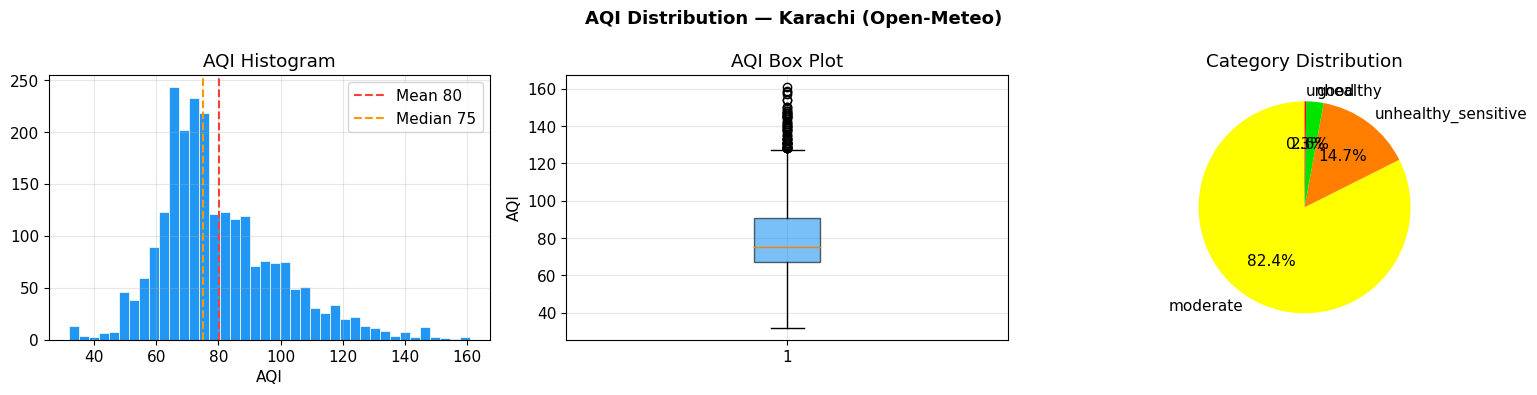

Skewness: 0.936 (>0 = right-skewed, log transform may help)


In [5]:
print('=== AQI Descriptive Statistics ===')
print(df['aqi'].describe().round(2))

print('\n=== AQI Category Distribution ===')
cats = df['aqi_category'].value_counts()
for cat, count in cats.items():
    pct = count / len(df) * 100
    print(f'  {cat:30s} {count:5d}  ({pct:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('AQI Distribution — Karachi (Open-Meteo)', fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(df['aqi'], bins=40, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['aqi'].mean(),   color=RED,    linestyle='--', label=f'Mean {df["aqi"].mean():.0f}')
axes[0].axvline(df['aqi'].median(), color=ORANGE, linestyle='--', label=f'Median {df["aqi"].median():.0f}')
axes[0].set_title('AQI Histogram')
axes[0].set_xlabel('AQI')
axes[0].legend()

# Box plot
axes[1].boxplot(df['aqi'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6))
axes[1].set_title('AQI Box Plot')
axes[1].set_ylabel('AQI')

# Category pie
aqi_colors = {
    'good': '#00e400', 'moderate': '#ffff00',
    'unhealthy_sensitive': '#ff7e00', 'unhealthy': '#ff0000',
    'very_unhealthy': '#8f3f97', 'hazardous': '#7e0023'
}
pie_colors = [aqi_colors.get(c, '#999') for c in cats.index]
axes[2].pie(cats.values, labels=cats.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Category Distribution')

plt.tight_layout()
plt.savefig('eda_distribution_new.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Skewness: {df["aqi"].skew():.3f} (>0 = right-skewed, log transform may help)')

## 5. Time-Series Patterns

=== Average AQI by Month ===
      mean    std  count
Feb  87.38  11.27    168
Mar  80.21  21.56    744
Apr  79.60  19.81    720
May  79.19  18.54    718
Jun  74.88   6.85      8

=== Average AQI by Hour of Day ===
hour
0     77.96
1     78.51
2     78.57
3     78.50
4     78.36
5     78.17
6     78.51
7     78.55
8     78.10
9     78.58
10    78.33
11    78.34
12    78.59
13    78.81
14    79.54
15    80.59
16    83.19
17    86.07
18    88.70
19    87.71
20    84.47
21    80.31
22    78.38
23    78.29

=== Average AQI by Day of Week (0=Mon) ===
Mon    80.85
Tue    78.72
Wed    80.60
Thu    79.48
Fri    78.78
Sat    79.07
Sun    83.79


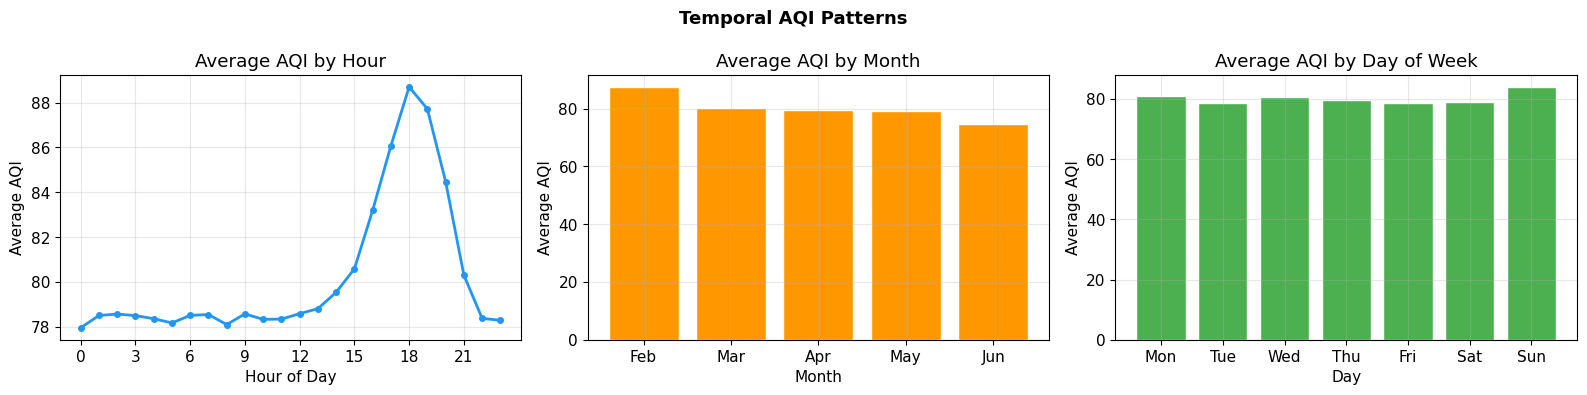

In [6]:
print('=== Average AQI by Month ===')
monthly = df.groupby('month')['aqi'].agg(['mean', 'std', 'count']).round(2)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly.index = [month_names.get(m, m) for m in monthly.index]
print(monthly.to_string())

print('\n=== Average AQI by Hour of Day ===')
hourly = df.groupby('hour')['aqi'].mean().round(2)
print(hourly.to_string())

print('\n=== Average AQI by Day of Week (0=Mon) ===')
daily = df.groupby('day_of_week')['aqi'].mean().round(2)
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
daily.index = [day_names.get(d, d) for d in daily.index]
print(daily.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Temporal AQI Patterns', fontsize=13, fontweight='bold')

hourly_vals = df.groupby('hour')['aqi'].mean()
axes[0].plot(hourly_vals.index, hourly_vals.values, color=BLUE, linewidth=2, marker='o', markersize=4)
axes[0].set_title('Average AQI by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average AQI')
axes[0].set_xticks(range(0, 24, 3))

monthly_vals = df.groupby('month')['aqi'].mean()
axes[1].bar(monthly_vals.index, monthly_vals.values, color=ORANGE, edgecolor='white')
axes[1].set_title('Average AQI by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average AQI')
axes[1].set_xticks(monthly_vals.index)
axes[1].set_xticklabels([month_names.get(m, m) for m in monthly_vals.index])

daily_vals = df.groupby('day_of_week')['aqi'].mean()
axes[2].bar(range(len(daily_vals)), daily_vals.values, color=GREEN, edgecolor='white')
axes[2].set_title('Average AQI by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Average AQI')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

plt.tight_layout()
plt.savefig('eda_temporal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Full Time-Series Plot

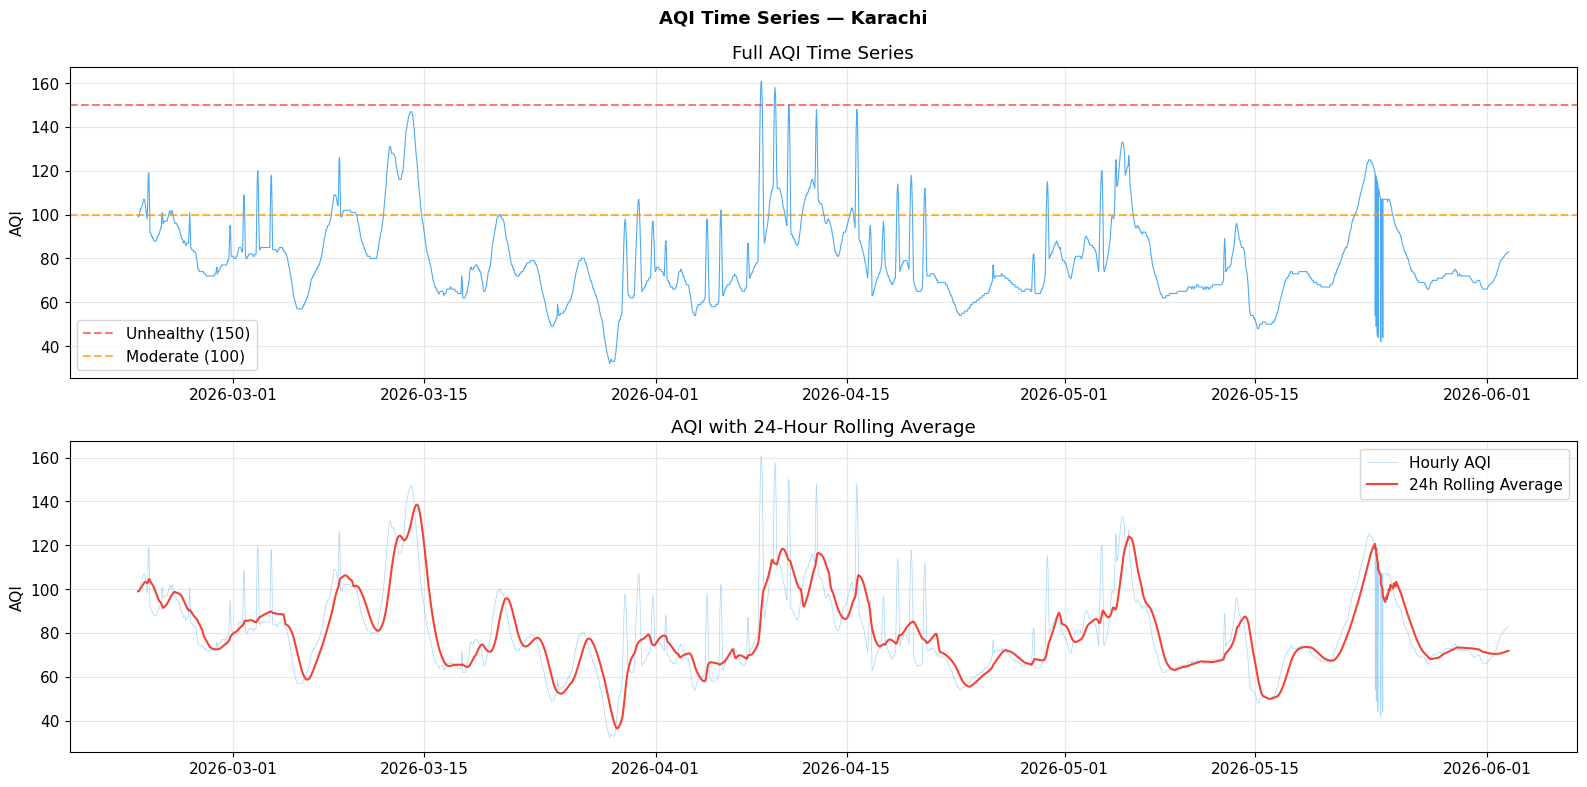

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('AQI Time Series — Karachi', fontsize=13, fontweight='bold')

axes[0].plot(df['timestamp'], df['aqi'], color=BLUE, linewidth=0.8, alpha=0.8)
axes[0].axhline(150, color=RED,    linestyle='--', alpha=0.7, label='Unhealthy (150)')
axes[0].axhline(100, color=ORANGE, linestyle='--', alpha=0.7, label='Moderate (100)')
axes[0].set_title('Full AQI Time Series')
axes[0].set_ylabel('AQI')
axes[0].legend()

# 24-hour rolling average
df_plot = df.copy()
df_plot['aqi_rolling_24h_plot'] = df_plot['aqi'].rolling(24, min_periods=1).mean()
axes[1].plot(df_plot['timestamp'], df_plot['aqi'],
             color=BLUE, linewidth=0.5, alpha=0.4, label='Hourly AQI')
axes[1].plot(df_plot['timestamp'], df_plot['aqi_rolling_24h_plot'],
             color=RED, linewidth=1.5, label='24h Rolling Average')
axes[1].set_title('AQI with 24-Hour Rolling Average')
axes[1].set_ylabel('AQI')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_timeseries_new.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Feature Correlations with AQI

=== Pearson Correlation with AQI (sorted) ===
  aqi_lag_1h                +0.9743  █████████████████████████████
  aqi_rolling_3h            +0.9468  ████████████████████████████
  aqi_lag_2h                +0.9374  ████████████████████████████
  aqi_rolling_6h            +0.9117  ███████████████████████████
  aqi_lag_3h                +0.8953  ██████████████████████████
  aqi_rolling_12h           +0.8701  ██████████████████████████
  aqi_rolling_24h           +0.8103  ████████████████████████
  aqi_lag_6h                +0.8083  ████████████████████████
  aqi_lag_12h               +0.7158  █████████████████████
  pm2_5                     +0.6508  ███████████████████
  aqi_lag_24h               +0.6194  ██████████████████
  pm10                      +0.5066  ███████████████
  co                        +0.2459  ███████
  no2                       +0.1831  █████
  so2                       +0.1771  █████
  o3                        +0.1673  █████
  aqi_change_rate           +0.1182  ██

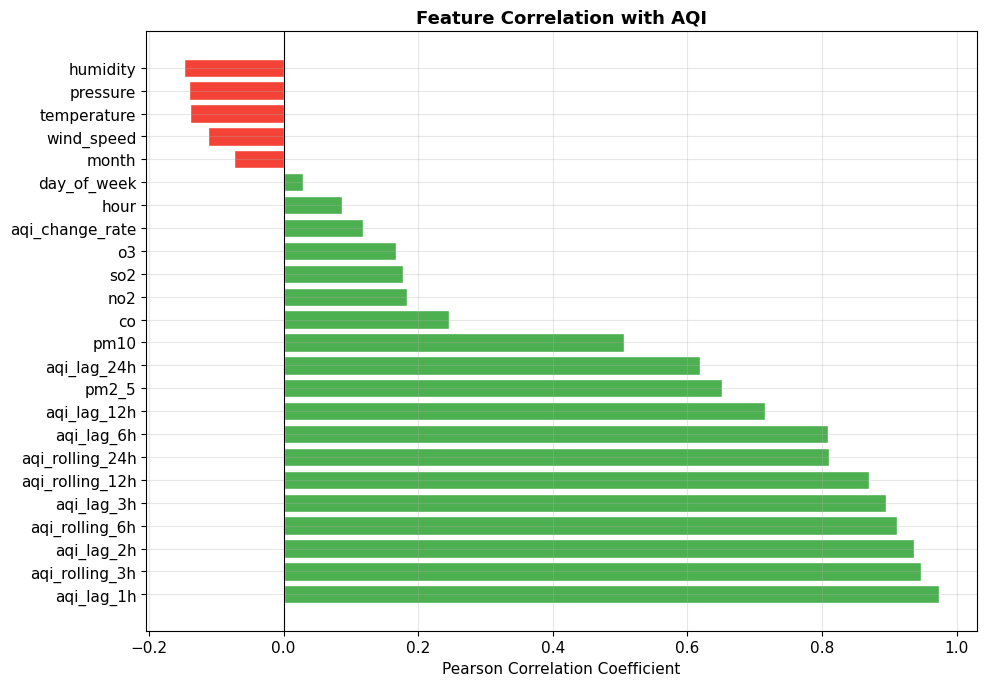

In [8]:
all_feature_cols = [
    'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2',
    'temperature', 'humidity', 'pressure', 'wind_speed',
    'hour', 'day_of_week', 'month',
    'aqi_lag_1h', 'aqi_lag_2h', 'aqi_lag_3h',
    'aqi_lag_6h', 'aqi_lag_12h', 'aqi_lag_24h',
    'aqi_rolling_3h', 'aqi_rolling_6h',
    'aqi_rolling_12h', 'aqi_rolling_24h',
    'aqi_change_rate'
]
feature_cols = [c for c in all_feature_cols if c in df.columns]

corr = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)

print('=== Pearson Correlation with AQI (sorted) ===')
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:25s} {sign}{abs(val):.4f}  {bar}')

fig, ax = plt.subplots(figsize=(10, 7))
colors = [GREEN if v > 0 else RED for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with AQI', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('eda_correlation_new.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Pollutant Distributions and Skewness

=== Pollutant Statistics ===
          pm2_5      pm10       no2        o3        co       so2
count  2358.000  2358.000  2358.000  2358.000  2358.000  2358.000
mean     25.126    57.693    16.225    80.391   389.076    12.220
std       9.901    37.800    11.858    35.807   230.384     6.139
min       3.500     3.700     0.030     7.000    86.200     0.200
25%      18.200    34.125     6.700    52.000   235.000     7.625
50%      23.200    47.300    12.900    73.000   314.000    11.500
75%      30.275    68.700    22.500   104.000   479.000    15.400
max      75.000   504.800    70.100   203.000  2118.000    41.500

=== Skewness (>1 = strongly right-skewed, log transform recommended) ===
  pm2_5       skew =  1.126 ← log transform recommended
  pm10        skew =  2.706 ← log transform recommended
  no2         skew =  1.249 ← log transform recommended
  o3          skew =  0.649
  co          skew =  1.983 ← log transform recommended
  so2         skew =  1.047 ← log transform recomme

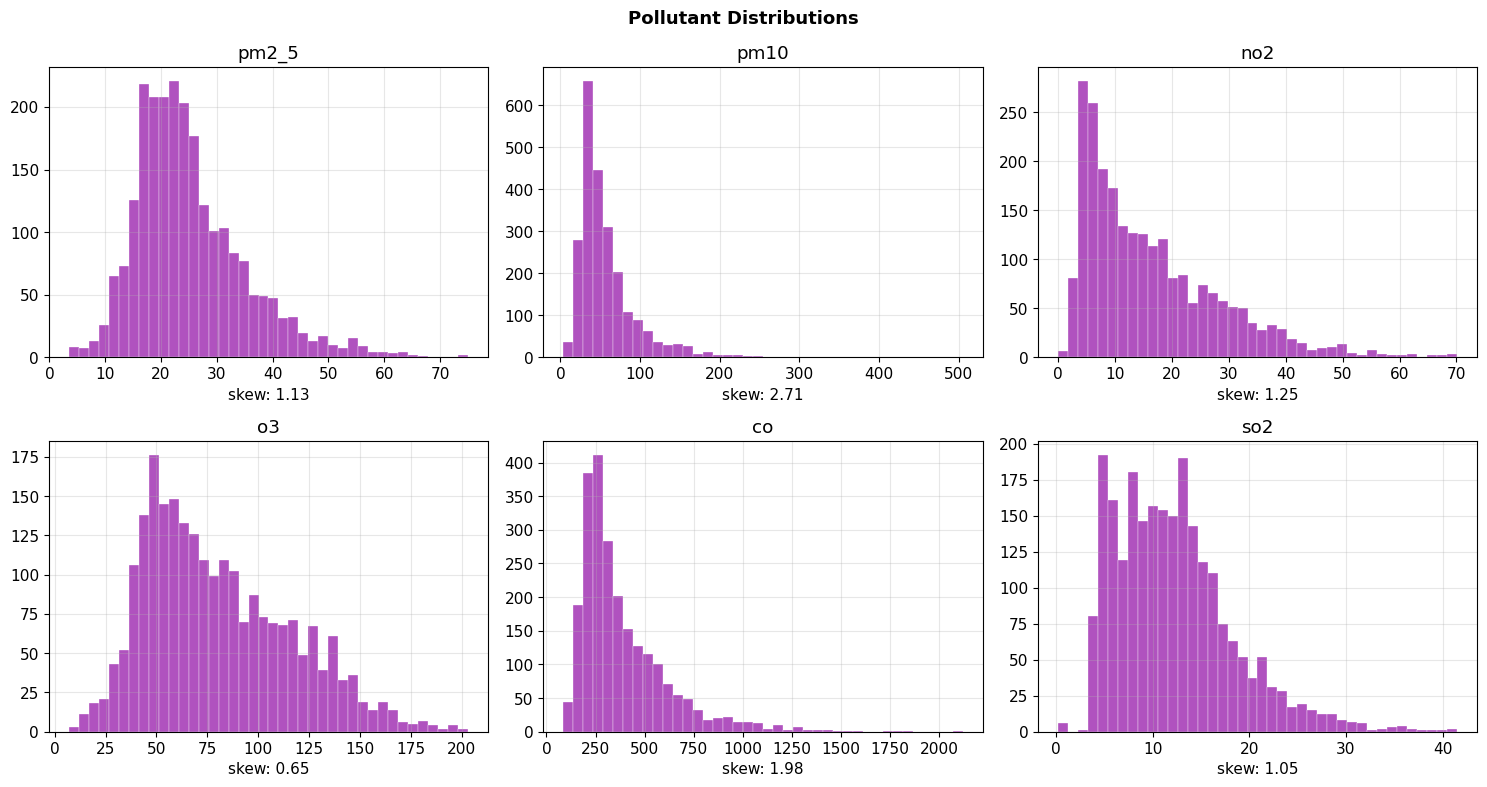

In [9]:
pollutants = ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']
pollutants = [p for p in pollutants if p in df.columns]

print('=== Pollutant Statistics ===')
print(df[pollutants].describe().round(3).to_string())

print('\n=== Skewness (>1 = strongly right-skewed, log transform recommended) ===')
for p in pollutants:
    sk = df[p].skew()
    flag = ' ← log transform recommended' if abs(sk) > 1 else ''
    print(f'  {p:10s}  skew = {sk:6.3f}{flag}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pollutant Distributions', fontsize=13, fontweight='bold')

for ax, p in zip(axes.flatten(), pollutants):
    ax.hist(df[p].dropna(), bins=40, color=PURPLE, edgecolor='white', linewidth=0.3, alpha=0.8)
    ax.set_title(p)
    ax.set_xlabel(f'skew: {df[p].skew():.2f}')

plt.tight_layout()
plt.savefig('eda_pollutants_new.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Lag and Rolling Feature Analysis

=== Lag Feature Correlations with AQI ===
  aqi_lag_1h                 r = 0.9743
  aqi_rolling_3h             r = 0.9468
  aqi_lag_2h                 r = 0.9374
  aqi_rolling_6h             r = 0.9117
  aqi_lag_3h                 r = 0.8953
  aqi_rolling_12h            r = 0.8701
  aqi_rolling_24h            r = 0.8103
  aqi_lag_6h                 r = 0.8083
  aqi_lag_12h                r = 0.7158
  aqi_lag_24h                r = 0.6194
  aqi_change_rate            r = 0.1182

=== Autocorrelation: AQI vs AQI lagged N hours ===
  lag  1h   autocorr = 0.9546
  lag  2h   autocorr = 0.9232
  lag  3h   autocorr = 0.8861
  lag  6h   autocorr = 0.7944
  lag 12h   autocorr = 0.7026
  lag 24h   autocorr = 0.6052
  lag 48h   autocorr = 0.3058


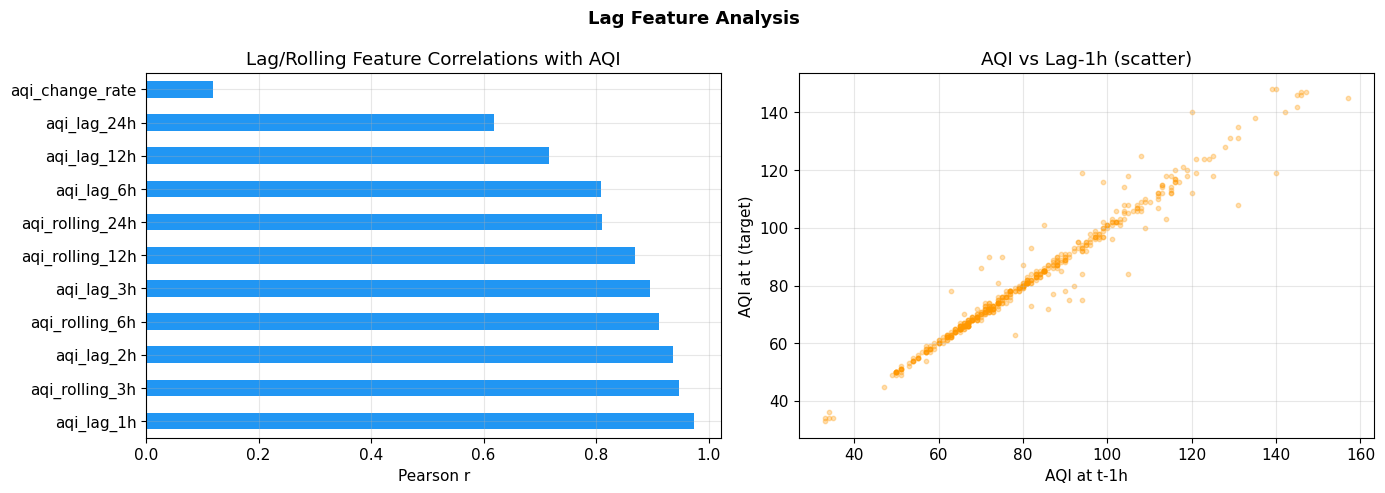

In [10]:
lag_cols     = [c for c in df.columns if 'aqi_lag'     in c]
rolling_cols = [c for c in df.columns if 'aqi_rolling' in c]
temporal     = lag_cols + rolling_cols + ['aqi_change_rate']
temporal     = [c for c in temporal if c in df.columns]

print('=== Lag Feature Correlations with AQI ===')
lag_corr = df[temporal + ['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)
for feat, val in lag_corr.items():
    print(f'  {feat:25s}  r = {val:.4f}')

print('\n=== Autocorrelation: AQI vs AQI lagged N hours ===')
for lag in [1, 2, 3, 6, 12, 24, 48]:
    ac = df['aqi'].autocorr(lag=lag)
    print(f'  lag {lag:2d}h   autocorr = {ac:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lag Feature Analysis', fontsize=13, fontweight='bold')

lag_corr.plot(kind='barh', color=BLUE, ax=axes[0])
axes[0].set_title('Lag/Rolling Feature Correlations with AQI')
axes[0].set_xlabel('Pearson r')

if 'aqi_lag_1h' in df.columns:
    sample = df.sample(min(500, len(df)), random_state=42)
    axes[1].scatter(sample['aqi_lag_1h'], sample['aqi'],
                    alpha=0.3, color=ORANGE, s=10)
    axes[1].set_xlabel('AQI at t-1h')
    axes[1].set_ylabel('AQI at t (target)')
    axes[1].set_title('AQI vs Lag-1h (scatter)')

plt.tight_layout()
plt.savefig('eda_lag_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Weather Feature Analysis

=== Weather Feature Statistics ===
       temperature  humidity  pressure  wind_speed
count      2358.00   2358.00   2358.00     2358.00
mean          7.36     18.51    245.77        3.31
std          12.98     33.09    431.88        6.08
min           0.00      0.00      0.00        0.00
25%           0.00      0.00      0.00        0.00
50%           0.00      0.00      0.00        0.00
75%           0.00      0.00      0.00        0.00
max          36.60     97.00   1010.00       22.40

=== Correlation of Weather Features with AQI ===
  temperature      r = -0.1392
  humidity         r = -0.1482
  pressure         r = -0.1409
  wind_speed       r = -0.1126

=== Wind Speed vs AQI (binned) ===
wind_bin
(-0.0224, 4.48]    81.8
(4.48, 8.96]       66.7
(8.96, 13.44]      75.0
(13.44, 17.92]     76.7
(17.92, 22.4]      80.8

=== Humidity vs AQI (binned) ===
hum_bin
(-0.097, 19.4]    81.8
(19.4, 38.8]      94.7
(38.8, 58.2]      74.8
(58.2, 77.6]      76.1
(77.6, 97.0]      74.7


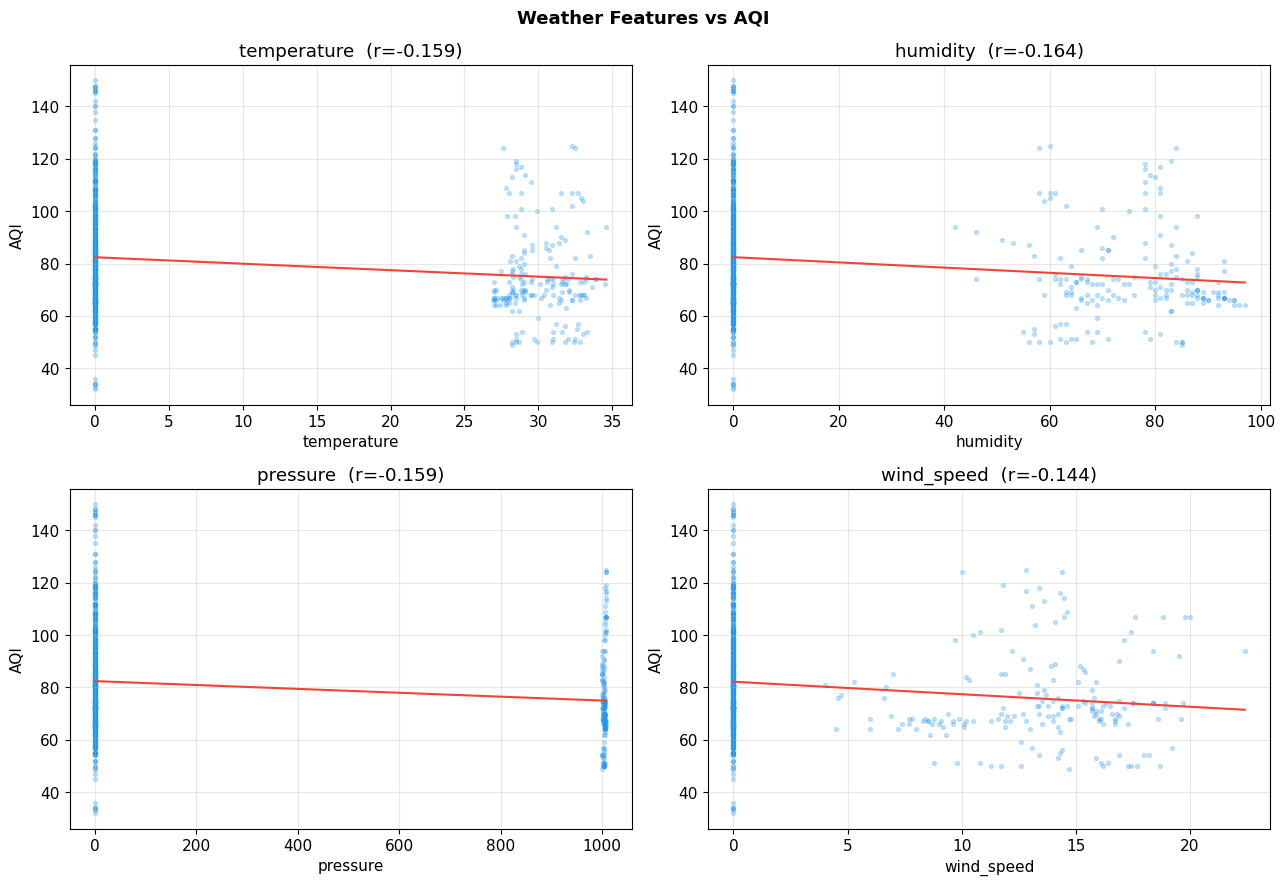

In [11]:
weather_cols = ['temperature', 'humidity', 'pressure', 'wind_speed']
weather_cols = [c for c in weather_cols if c in df.columns]

print('=== Weather Feature Statistics ===')
print(df[weather_cols].describe().round(2).to_string())

print('\n=== Correlation of Weather Features with AQI ===')
for col in weather_cols:
    r = df[col].corr(df['aqi'])
    print(f'  {col:15s}  r = {r:.4f}')

print('\n=== Wind Speed vs AQI (binned) ===')
df['wind_bin'] = pd.cut(df['wind_speed'], bins=5)
print(df.groupby('wind_bin', observed=True)['aqi'].mean().round(1).to_string())

print('\n=== Humidity vs AQI (binned) ===')
df['hum_bin'] = pd.cut(df['humidity'], bins=5)
print(df.groupby('hum_bin', observed=True)['aqi'].mean().round(1).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Weather Features vs AQI', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), weather_cols):
    sample = df.sample(min(800, len(df)), random_state=42)
    ax.scatter(sample[col], sample['aqi'], alpha=0.25, color=BLUE, s=8)
    # trend line
    z = np.polyfit(sample[col].dropna(), sample.loc[sample[col].notna(), 'aqi'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(xs, p(xs), color=RED, linewidth=1.5)
    r = sample[col].corr(sample['aqi'])
    ax.set_title(f'{col}  (r={r:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')

plt.tight_layout()
plt.savefig('eda_weather.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Correlation Heatmap

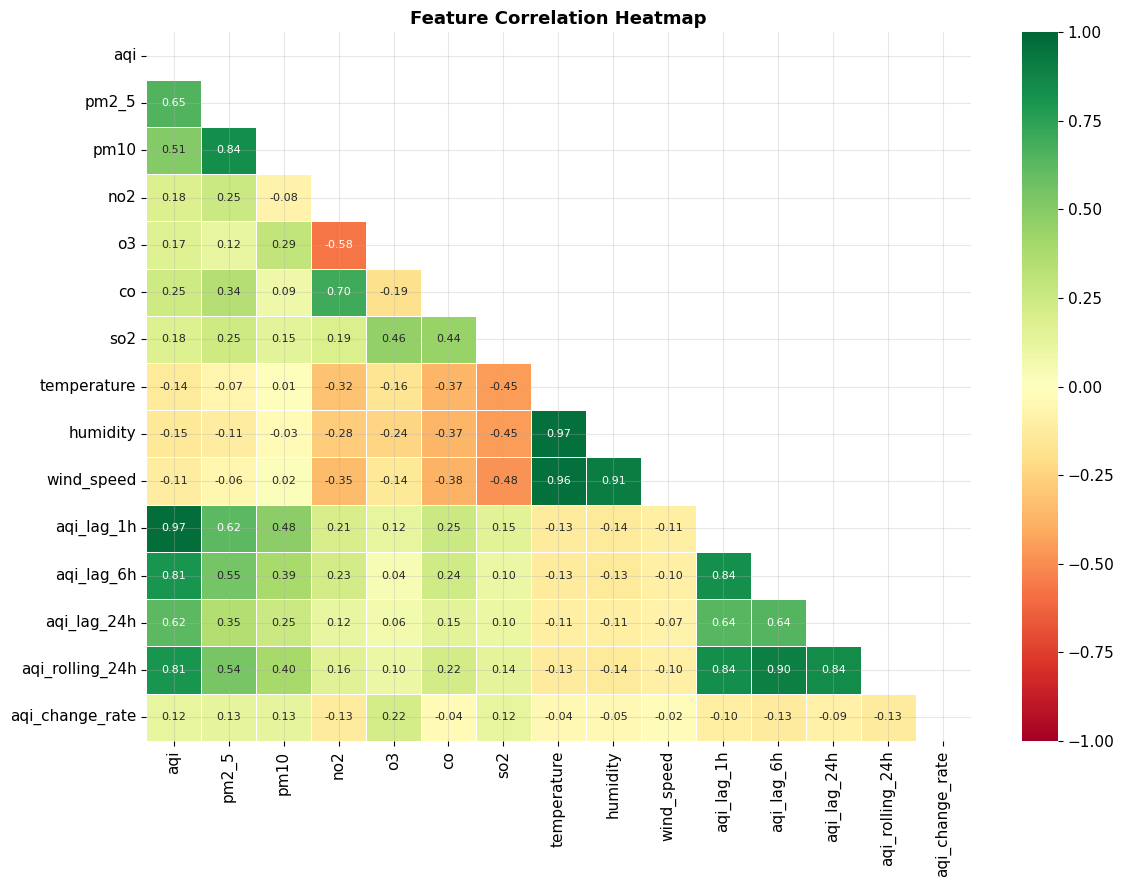

In [12]:
heatmap_cols = [
    'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2',
    'temperature', 'humidity', 'wind_speed',
    'aqi_lag_1h', 'aqi_lag_6h', 'aqi_lag_24h',
    'aqi_rolling_24h', 'aqi_change_rate'
]
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.4, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Interaction Feature Validation

In [13]:
# Validate that the interaction features in training_pipeline.py are useful
df['pm2_5_x_humidity'] = df['pm2_5'] * df['humidity'] / 100
df['pm10_x_humidity']  = df['pm10']  * df['humidity'] / 100
df['pm2_5_x_wind']     = df['pm2_5'] / (df['wind_speed'] + 1)
df['pm10_x_wind']      = df['pm10']  / (df['wind_speed'] + 1)

if 'aqi_lag_3h' in df.columns:
    df['aqi_momentum_3h'] = (df['aqi'] - df['aqi_lag_3h']) / 3.0

for col in ['pm2_5', 'pm10', 'co', 'so2']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

interaction_cols = [
    'pm2_5_x_humidity', 'pm10_x_humidity',
    'pm2_5_x_wind', 'pm10_x_wind',
    'aqi_momentum_3h',
    'log_pm2_5', 'log_pm10', 'log_co', 'log_so2'
]
interaction_cols = [c for c in interaction_cols if c in df.columns]

print('=== Interaction Feature Correlations with AQI ===')
for col in interaction_cols:
    r_interact = df[col].corr(df['aqi'])
    base       = col.split('_x_')[0].replace('log_','').replace('_momentum_3h','')
    r_base     = df[base].corr(df['aqi']) if base in df.columns else None
    improvement = ''
    if r_base is not None:
        diff = abs(r_interact) - abs(r_base)
        improvement = f'  (base {base} r={r_base:.4f}, delta={diff:+.4f})'
    print(f'  {col:25s}  r = {r_interact:.4f}{improvement}')

=== Interaction Feature Correlations with AQI ===
  pm2_5_x_humidity           r = -0.0075  (base pm2_5 r=0.6508, delta=-0.6432)
  pm10_x_humidity            r = 0.0212  (base pm10 r=0.5066, delta=-0.4854)
  pm2_5_x_wind               r = 0.4736  (base pm2_5 r=0.6508, delta=-0.1771)
  pm10_x_wind                r = 0.4415  (base pm10 r=0.5066, delta=-0.0651)
  aqi_momentum_3h            r = 0.2273  (base aqi r=1.0000, delta=-0.7727)
  log_pm2_5                  r = 0.6516  (base pm2_5 r=0.6508, delta=+0.0008)
  log_pm10                   r = 0.5554  (base pm10 r=0.5066, delta=+0.0488)
  log_co                     r = 0.2703  (base co r=0.2459, delta=+0.0243)
  log_so2                    r = 0.1707  (base so2 r=0.1771, delta=-0.0064)


## 13. Summary and Recommendations

In [14]:
print('=' * 65)
print('EDA SUMMARY AND TRAINING RECOMMENDATIONS')
print('=' * 65)

print(f'''
DATASET
  Records       : {len(df)}
  Date range    : {df['timestamp'].min().date()} to {df['timestamp'].max().date()}
  AQI mean/std  : {df['aqi'].mean():.1f} / {df['aqi'].std():.1f}
  AQI median    : {df['aqi'].median():.1f}
  AQI skewness  : {df['aqi'].skew():.3f}
''')

print('DATA QUALITY')
bad = df[(df['aqi'] >= 400) & (df['pm2_5'] < 50)]
print(f'  AQI>=400 with pm2_5<50 (errors) : {len(bad)} records')
if len(bad) > 0:
    print('  → These are API errors. Clean before training.')
else:
    print('  → No suspicious AQI=500 errors found in this dataset.')
    print('    (Data quality improved vs old OpenWeather source)')

print('\nSTRONGEST PREDICTORS (top 5 by |correlation|)')
corr_sorted = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').abs().sort_values(ascending=False)
for feat, val in corr_sorted.head(5).items():
    print(f'  {feat:25s}  |r| = {val:.4f}')

print('\nFEATURE ENGINEERING VALIDATION')
for col in interaction_cols:
    r = df[col].corr(df['aqi'])
    print(f'  {col:25s}  r = {r:.4f}')

print('\nSKEWNESS — LOG TRANSFORM NEEDED?')
for p in pollutants:
    sk = df[p].skew()
    needed = 'YES' if abs(sk) > 1 else 'no'
    print(f'  {p:10s}  skew={sk:6.3f}  log transform: {needed}')

print('\nTEMPORAL PATTERNS')
worst_month  = df.groupby('month')['aqi'].mean().idxmax()
best_month   = df.groupby('month')['aqi'].mean().idxmin()
worst_hour   = df.groupby('hour')['aqi'].mean().idxmax()
best_hour    = df.groupby('hour')['aqi'].mean().idxmin()
print(f'  Worst month  : {month_names.get(worst_month, worst_month)} (avg AQI {df.groupby("month")["aqi"].mean()[worst_month]:.1f})')
print(f'  Best month   : {month_names.get(best_month, best_month)} (avg AQI {df.groupby("month")["aqi"].mean()[best_month]:.1f})')
print(f'  Worst hour   : {worst_hour:02d}:00 (avg AQI {df.groupby("hour")["aqi"].mean()[worst_hour]:.1f})')
print(f'  Best hour    : {best_hour:02d}:00 (avg AQI {df.groupby("hour")["aqi"].mean()[best_hour]:.1f})')
print(f'  hour/AQI r   : {df["hour"].corr(df["aqi"]):.4f} (use sin/cos encoding, not raw hour)')

print('\nMODEL RECOMMENDATIONS')
print('  1. Target: AQI at t+1h (1-step-ahead, iterated 72x for 3-day forecast)')
print('  2. Best base models: XGBoost, RandomForest, GradientBoosting')
print('  3. Stacking ensemble (RF+XGB+GB -> Ridge meta) expected best R2')
print('  4. Feature set: pollutants + log-pollutants + interactions + lag/rolling + cyclical time')
print('  5. Train/test split: chronological (no shuffle) — time series rule')
print('=' * 65)

EDA SUMMARY AND TRAINING RECOMMENDATIONS

DATASET
  Records       : 2358
  Date range    : 2026-02-22 to 2026-06-02
  AQI mean/std  : 80.2 / 19.6
  AQI median    : 75.0
  AQI skewness  : 0.936

DATA QUALITY
  AQI>=400 with pm2_5<50 (errors) : 0 records
  → No suspicious AQI=500 errors found in this dataset.
    (Data quality improved vs old OpenWeather source)

STRONGEST PREDICTORS (top 5 by |correlation|)
  aqi_lag_1h                 |r| = 0.9743
  aqi_rolling_3h             |r| = 0.9468
  aqi_lag_2h                 |r| = 0.9374
  aqi_rolling_6h             |r| = 0.9117
  aqi_lag_3h                 |r| = 0.8953

FEATURE ENGINEERING VALIDATION
  pm2_5_x_humidity           r = -0.0075
  pm10_x_humidity            r = 0.0212
  pm2_5_x_wind               r = 0.4736
  pm10_x_wind                r = 0.4415
  aqi_momentum_3h            r = 0.2273
  log_pm2_5                  r = 0.6516
  log_pm10                   r = 0.5554
  log_co                     r = 0.2703
  log_so2                  